In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
ipl = pd.read_csv("ipl_matches_2008_2024.csv", parse_dates=['date'])
ipl.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
ipl.isnull().sum()

ipl['city'] = ipl['city'].fillna('Unknown')
ipl['player_of_match'] = ipl['player_of_match'].fillna('Not Awarded')
ipl['winner'] = ipl['winner'].fillna('No Result')
ipl['result_margin'] = ipl['result_margin'].fillna(0)
ipl['target_runs'] = ipl['target_runs'].fillna(0)
ipl['target_overs'] = ipl['target_overs'].fillna(0)
ipl['method'] = ipl['method'].fillna('Normal')

ipl.isnull().sum()

id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64

In [5]:
team_name_corrections = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad'
}

ipl.replace(team_name_corrections, inplace=True)

team_name_map = {
    'Delhi Capitals': 'DC',
    'Sunrisers Hyderabad': 'SRH',
    'Kings XI Punjab': 'PBKS',
    'Punjab Kings': 'PBKS',
    'Rising Pune Supergiant': 'RPS',
    'Rising Pune Supergiants': 'RPS',
    'Pune Warriors': 'PWI',
    'Royal Challengers Bangalore': 'RCB',
    'Mumbai Indians': 'MI',
    'Chennai Super Kings': 'CSK',
    'Kolkata Knight Riders': 'KKR',
    'Rajasthan Royals': 'RR',
    'Gujarat Lions': 'GL',
    'Gujarat Titans': 'GT',
    'Lucknow Super Giants': 'LSG'
}

ipl.replace(team_name_map, inplace=True)

In [6]:
ipl['match_type_code'] = ipl['match_type'].astype('category').cat.codes
ipl['season_short'] = ipl['season'].astype(str).str[-2:]

In [7]:
ipl.describe(include='all')

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,match_type_code,season_short
count,1.095000e+03,1095,1095,1095,1095,1095,1095,1095,1095,1095,...,1095,1095.000000,1095.000000,1095.000000,1095,1095,1095,1095,1095.000000,1095
unique,NaN,17,37,NaN,8,292,58,15,15,15,...,4,NaN,NaN,NaN,2,2,62,62,NaN,16
top,NaN,2013,Mumbai,NaN,League,AB de Villiers,Eden Gardens,RCB,MI,MI,...,wickets,NaN,NaN,NaN,N,Normal,AK Chaudhary,S Ravi,NaN,21
freq,NaN,76,173,NaN,1029,25,77,135,138,143,...,578,NaN,NaN,NaN,1081,1074,115,83,NaN,120
mean,9.048283e+05,NaN,NaN,2016-06-25 11:39:36.986301184,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,16.959817,165.230137,19.705205,NaN,NaN,NaN,NaN,4.007306,NaN
min,3.359820e+05,NaN,NaN,2008-04-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN
25%,5.483315e+05,NaN,NaN,2012-04-21 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,5.000000,146.000000,20.000000,NaN,NaN,NaN,NaN,4.000000,NaN
50%,9.809610e+05,NaN,NaN,2016-05-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,8.000000,166.000000,20.000000,NaN,NaN,NaN,NaN,4.000000,NaN
75%,1.254062e+06,NaN,NaN,2021-04-13 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,19.000000,187.000000,20.000000,NaN,NaN,NaN,NaN,4.000000,NaN
max,1.426312e+06,NaN,NaN,2024-05-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,146.000000,288.000000,20.000000,NaN,NaN,NaN,NaN,7.000000,NaN


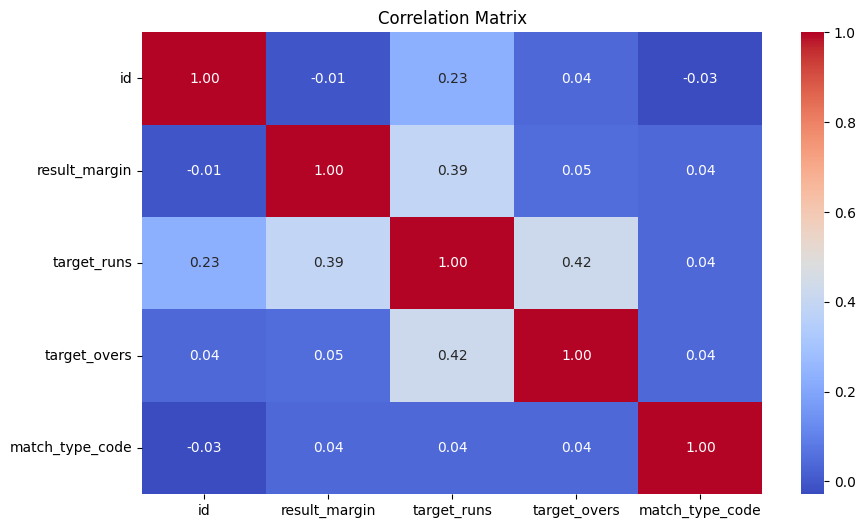

In [8]:
corr = ipl.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

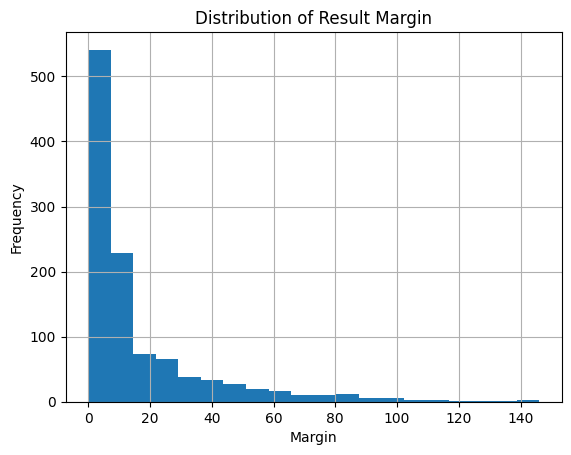

In [9]:
ipl['result_margin'].hist(bins=20)
plt.title("Distribution of Result Margin")
plt.xlabel("Margin")
plt.ylabel("Frequency")
plt.show()

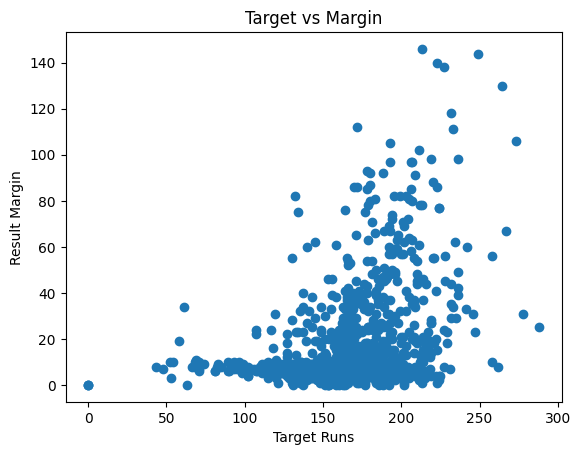

In [10]:
plt.scatter(ipl['target_runs'], ipl['result_margin'])
plt.xlabel("Target Runs")
plt.ylabel("Result Margin")
plt.title("Target vs Margin")
plt.show()

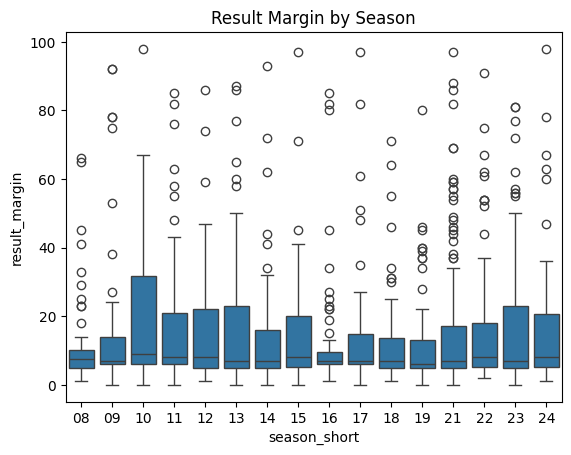

In [11]:
filtered = ipl[ipl['result_margin'] <= 100]

sns.boxplot(x='season_short', y='result_margin', data=filtered)
plt.title("Result Margin by Season")
plt.show()

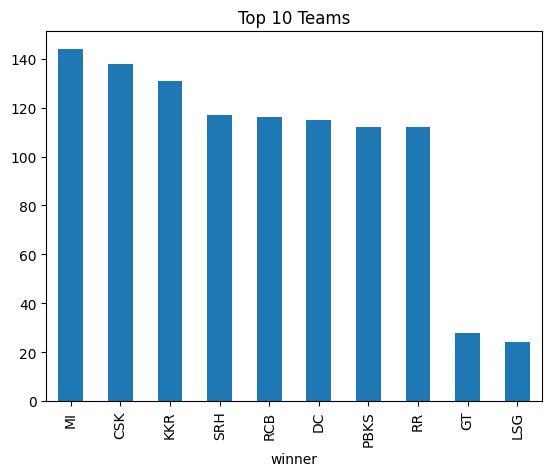

In [12]:
top_teams = ipl['winner'].value_counts().head(10)

top_teams.plot(kind='bar')
plt.title("Top 10 Teams")
plt.show()

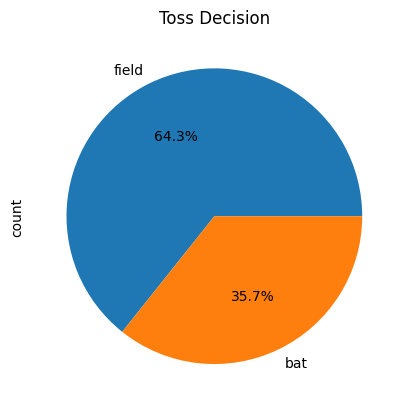

In [13]:
ipl['toss_decision'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Toss Decision")
plt.show()

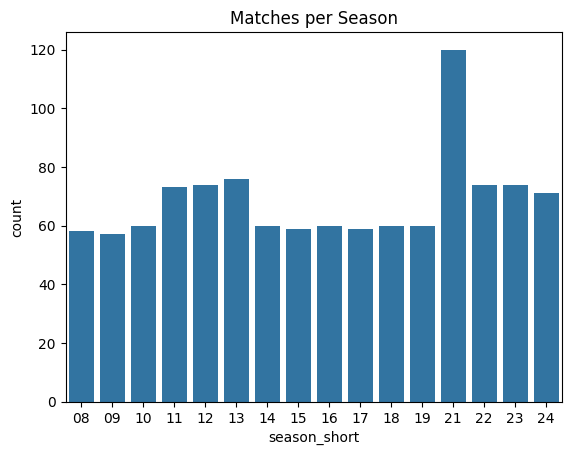

In [14]:
sns.countplot(x='season_short', data=ipl)
plt.title("Matches per Season")
plt.show()

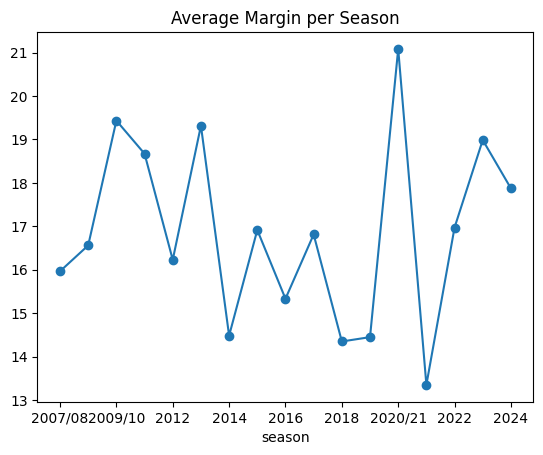

In [15]:
avg_margin = ipl.groupby('season')['result_margin'].mean()

avg_margin.plot(marker='o')
plt.title("Average Margin per Season")
plt.show()

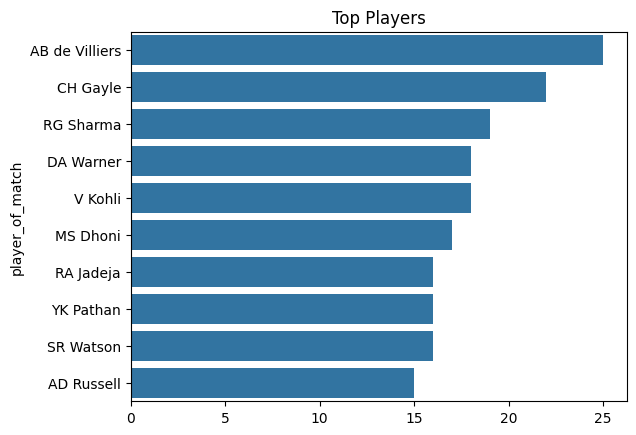

In [16]:
top_players = ipl['player_of_match'].value_counts().head(10)

sns.barplot(x=top_players.values, y=top_players.index)
plt.title("Top Players")
plt.show()

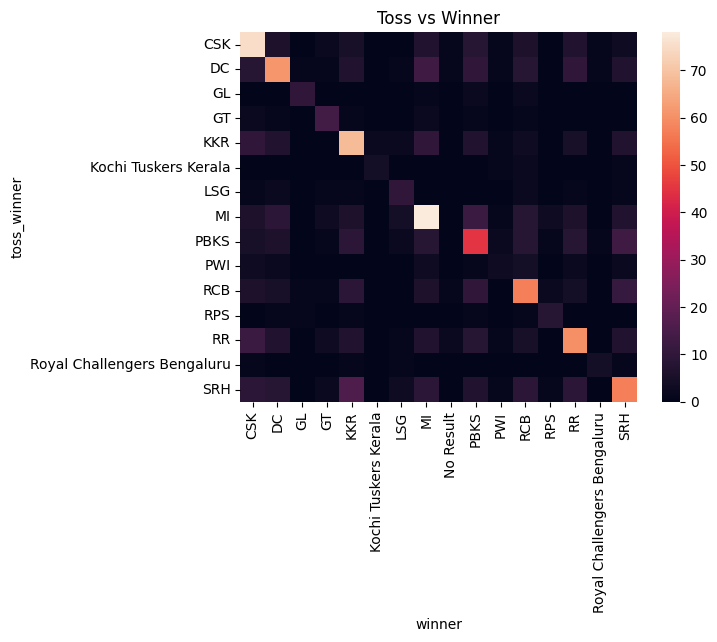

In [17]:
heatmap_data = pd.crosstab(ipl['toss_winner'], ipl['winner'])

sns.heatmap(heatmap_data)
plt.title("Toss vs Winner")
plt.show()

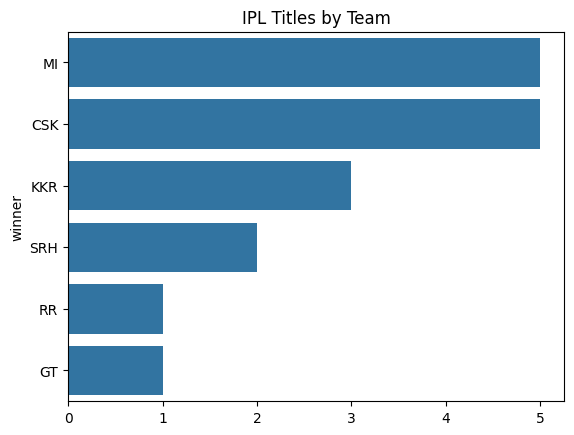

In [18]:
finals = ipl.sort_values('date').groupby('season').tail(1)
titles = finals['winner'].value_counts()

sns.barplot(x=titles.values, y=titles.index)
plt.title("IPL Titles by Team")
plt.show()